# 🎓 Smart Attendance System — Face Recognition

---

| Field | Details |
|---|---|
| **Project Title** | Smart Attendance System using Face Recognition |
| **Objective** | Automatically detect and recognize faces to mark attendance |
| **Input** | Uploaded images (known faces + test image) |
| **Technique** | Face Detection + Face Recognition |
| **Output** | Annotated image + CSV + Professional HTML Report |
| **Libraries** | `opencv-python`, `face_recognition`, `csv`, `datetime`, `matplotlib` |

---

### 📌 How it works:
1. Upload reference photos — one per person, named with their name (e.g. `Ahmed.jpg`)
2. Upload a test image (group photo or single person)
3. The system detects all faces and matches them against known people
4. Auto-generates annotated image + CSV + professional attendance report


## Install Required Libraries

In [1]:
print('⏳ Installing libraries... please wait.')
!pip install face_recognition opencv-python-headless matplotlib -q
print('✅ All libraries installed successfully!')

⏳ Installing libraries... please wait.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries installed successfully!


##  Upload Known Faces

>  **Important:** Name each file with the person's name — e.g. `’Mohammed.jpg`, `Neymar.png`

In [2]:
import os, cv2, csv, numpy as np, face_recognition, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from google.colab import files
from IPython.display import display, HTML

def banner(text, color='#2ecc71'):
    display(HTML(f'''
        <div style="background:{color};padding:12px 20px;border-radius:8px;
                    font-family:monospace;font-size:15px;color:white;font-weight:bold;">
            {text}
        </div>
    '''))

os.makedirs('known_faces', exist_ok=True)
banner('📤 Upload reference photos — name each file with the person\'s name (e.g. Ahmed.jpg)')
uploaded = files.upload()

for filename, data in uploaded.items():
    with open(os.path.join('known_faces', filename), 'wb') as f:
        f.write(data)

banner(f'✅ {len(uploaded)} photo(s) uploaded successfully!')

Saving Mohamed .jpeg to Mohamed .jpeg


##  Load & Encode Known Faces

> This step extracts a **128-dimension feature vector** from each face — the core of face recognition.

In [3]:
known_encodings, known_names, failed = [], [], []
print('🔍 Processing known faces...\n')

for filename in sorted(os.listdir('known_faces')):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join('known_faces', filename)
        image = face_recognition.load_image_file(img_path)
        image = cv2.resize(image, (600, 600))  # preprocessing: normalize size
        encodings = face_recognition.face_encodings(image)
        if encodings:
            known_encodings.append(encodings[0])
            known_names.append(os.path.splitext(filename)[0])
            print(f'   ✅  {os.path.splitext(filename)[0]}')
        else:
            failed.append(filename)
            print(f'   ⚠️  No face detected in: {filename}')

print(f'\n📊 {len(known_names)} face(s) loaded{" | " + str(len(failed)) + " failed" if failed else " — all good!"}')

🔍 Processing known faces...

   ✅  Mohamed 

📊 1 face(s) loaded — all good!


##  Upload Test Image & Run Recognition

Saving Neymar.jpg to Neymar.jpg

🔎 Detected 1 face(s).

   → Unknown  (26.1% match)


/tmp/ipykernel_1099/2810828858.py:70: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1099/2810828858.py:71: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  plt.savefig(output_img, dpi=150, bbox_inches='tight')
/tmp/ipykernel_1099/2810828858.py:71: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  plt.savefig(output_img, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


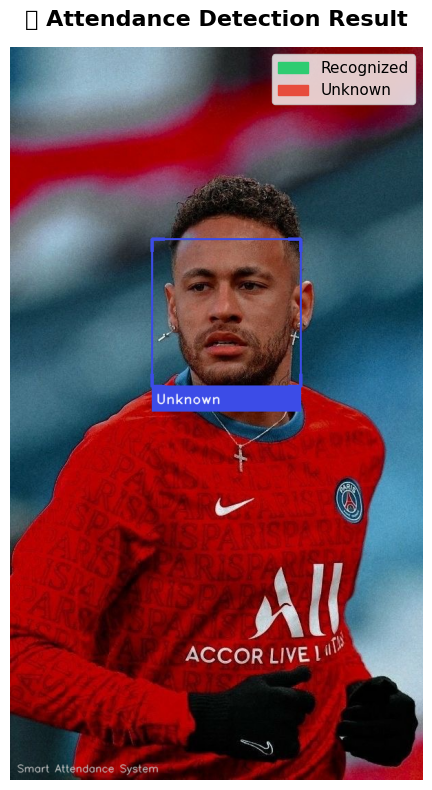


✅ Result displayed!


In [4]:
banner('📤 Upload the test image (group photo or single person)', color='#3498db')
test_upload = files.upload()
test_filename = list(test_upload.keys())[0]

# Load image
test_image_rgb = face_recognition.load_image_file(test_filename)
test_image_bgr = cv2.cvtColor(test_image_rgb, cv2.COLOR_RGB2BGR)

# PREPROCESSING: resize to 50% for speed
scale = 0.5
small = cv2.resize(test_image_rgb, (0, 0), fx=scale, fy=scale)
rgb_small = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)

# FEATURE EXTRACTION: detect face locations
face_locations = face_recognition.face_locations(rgb_small, model='hog')
face_encodings_detected = face_recognition.face_encodings(rgb_small, face_locations)
print(f'\n🔎 Detected {len(face_locations)} face(s).\n')

today = datetime.now().strftime('%Y-%m-%d')
attendance_log, results = [], []

# RECOGNITION: match each face
for face_encoding, face_location in zip(face_encodings_detected, face_locations):
    name, confidence = 'Unknown', 0.0
    if known_encodings:
        distances = face_recognition.face_distance(known_encodings, face_encoding)
        best_idx = int(np.argmin(distances))
        confidence = round((1 - distances[best_idx]) * 100, 1)
        if distances[best_idx] < 0.5:
            name = known_names[best_idx]

    results.append((name, confidence, face_location))
    now = datetime.now()
    attendance_log.append({'Name': name, 'Date': now.strftime('%Y-%m-%d'),
                           'Time': now.strftime('%H:%M:%S'),
                           'Confidence': f'{confidence}%',
                           'Status': 'Present' if name != 'Unknown' else 'Unknown'})
    print(f'   → {name}  ({confidence}% match)')

# DRAW ANNOTATIONS
for name, confidence, face_location in results:
    top, right, bottom, left = [int(v / scale) for v in face_location]
    is_known  = name != 'Unknown'
    box_color = (46, 204, 113) if is_known else (231, 76, 60)
    label     = f'{name}  {confidence}%' if is_known else 'Unknown'

    cv2.rectangle(test_image_bgr, (left, top), (right, bottom), box_color, 2)
    cv2.rectangle(test_image_bgr, (left, bottom), (right, bottom + 36), box_color, cv2.FILLED)
    cv2.putText(test_image_bgr, label, (left + 6, bottom + 25),
                cv2.FONT_HERSHEY_DUPLEX, 0.65, (255,255,255), 1, cv2.LINE_AA)
    for (x, y, dx, dy) in [(left,top,1,1),(right,top,-1,1),(left,bottom,1,-1),(right,bottom,-1,-1)]:
        cv2.line(test_image_bgr, (x, y), (x + dx*18, y), box_color, 3)
        cv2.line(test_image_bgr, (x, y), (x, y + dy*18), box_color, 3)

h, w = test_image_bgr.shape[:2]
cv2.putText(test_image_bgr, 'Smart Attendance System',
            (10, h - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1, cv2.LINE_AA)

output_img = 'attendance_result.jpg'
cv2.imwrite(output_img, test_image_bgr)
result_rgb = cv2.cvtColor(test_image_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(result_rgb)
plt.axis('off')
plt.title('🎓 Attendance Detection Result', fontsize=16, fontweight='bold', pad=15)
plt.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Recognized'),
    mpatches.Patch(color='#e74c3c', label='Unknown')
], loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig(output_img, dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Result displayed!')

##  Save CSV Attendance File

In [5]:
csv_file = f'attendance_{today}.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['Name','Date','Time','Confidence','Status'])
    writer.writeheader()
    writer.writerows(attendance_log)

banner(f'✅ CSV saved: {csv_file}')
print(f'   Rows: {len(attendance_log)}')

   Rows: 1


##  Generate Professional Attendance Report

Name,Date,Time,Confidence,Status
Unknown,2026-05-04,19:10:11,26.1%,✘ Unknown

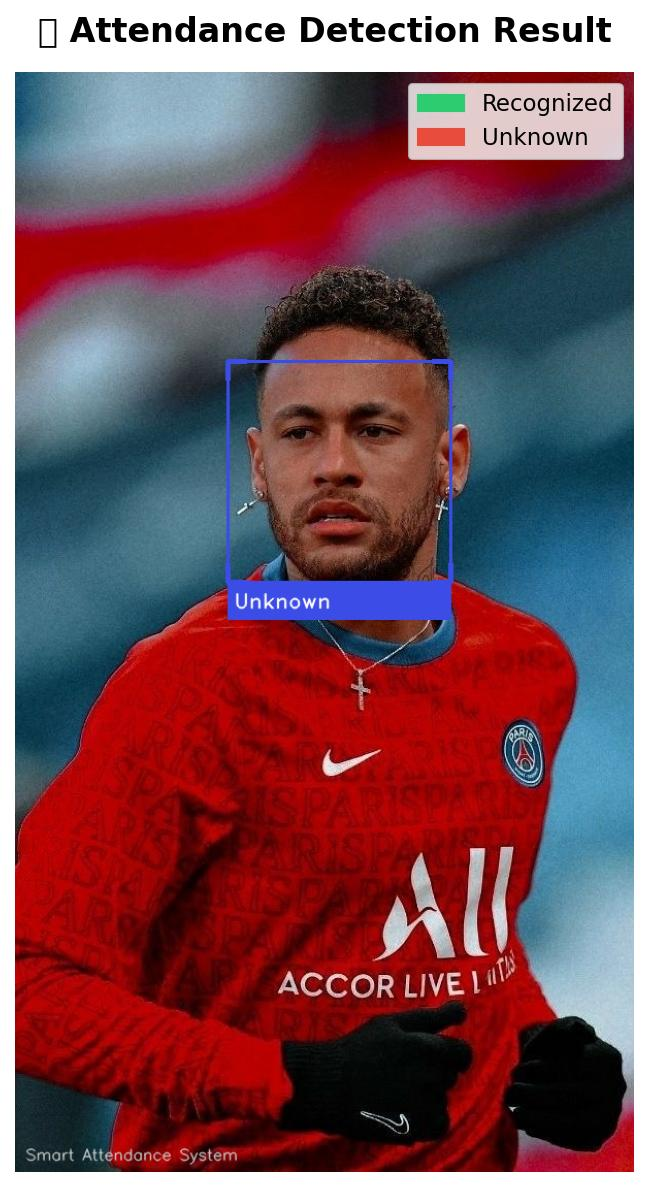

In [6]:
import base64

present_list = [r for r in attendance_log if r['Status'] == 'Present']
unknown_list = [r for r in attendance_log if r['Status'] == 'Unknown']
total = len(attendance_log)

# Encode result image as base64 to embed in HTML
with open(output_img, 'rb') as img_f:
    img_b64 = base64.b64encode(img_f.read()).decode()

# Build rows HTML
rows_html = ''
for i, r in enumerate(attendance_log):
    bg = '#f8faff' if i % 2 == 0 else '#ffffff'
    status_badge = (
        '<span style="background:#e8f8ef;color:#1a7a42;padding:3px 12px;border-radius:20px;font-weight:600;font-size:13px;">✔ Present</span>'
        if r['Status'] == 'Present' else
        '<span style="background:#fdecea;color:#c0392b;padding:3px 12px;border-radius:20px;font-weight:600;font-size:13px;">✘ Unknown</span>'
    )
    rows_html += f'''
        <tr style="background:{bg};">
            <td style="padding:12px 16px;border-bottom:1px solid #eef0f5;font-weight:600;color:#1b3a6b;">{r["Name"]}</td>
            <td style="padding:12px 16px;border-bottom:1px solid #eef0f5;color:#555;">{r["Date"]}</td>
            <td style="padding:12px 16px;border-bottom:1px solid #eef0f5;color:#555;">{r["Time"]}</td>
            <td style="padding:12px 16px;border-bottom:1px solid #eef0f5;color:#555;">{r["Confidence"]}</td>
            <td style="padding:12px 16px;border-bottom:1px solid #eef0f5;">{status_badge}</td>
        </tr>
    '''

html_report = f'''
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>Smart Attendance Report</title>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap');
    * {{ margin:0; padding:0; box-sizing:border-box; }}
    body {{ font-family:'Inter',sans-serif; background:#f0f4ff; color:#222; }}
    .page {{ max-width:900px; margin:40px auto; background:#fff; border-radius:20px;
             box-shadow:0 8px 40px rgba(27,58,107,0.13); overflow:hidden; }}
    .header {{ background:linear-gradient(135deg,#1b3a6b 0%,#2563eb 100%);
               padding:48px 48px 36px; color:#fff; }}
    .header h1 {{ font-size:32px; font-weight:900; letter-spacing:-0.5px; margin-bottom:6px; }}
    .header p  {{ font-size:15px; opacity:0.8; margin-bottom:20px; }}
    .meta {{ display:flex; gap:24px; font-size:13px; opacity:0.85; }}
    .meta span {{ background:rgba(255,255,255,0.15); padding:4px 14px; border-radius:20px; }}
    .body {{ padding:40px 48px; }}
    .stats {{ display:grid; grid-template-columns:repeat(3,1fr); gap:20px; margin-bottom:36px; }}
    .stat {{ background:#f8faff; border:1.5px solid #e0e7ff; border-radius:14px;
             padding:24px; text-align:center; }}
    .stat .num {{ font-size:48px; font-weight:900; line-height:1; margin-bottom:6px; }}
    .stat .lbl {{ font-size:13px; color:#777; font-weight:600; text-transform:uppercase; letter-spacing:.5px; }}
    .stat.total .num {{ color:#1b3a6b; }}
    .stat.present .num {{ color:#1a7a42; }}
    .stat.unknown .num {{ color:#c0392b; }}
    .section-title {{ font-size:18px; font-weight:700; color:#1b3a6b;
                      margin-bottom:16px; padding-bottom:10px;
                      border-bottom:3px solid #2563eb; display:inline-block; }}
    table {{ width:100%; border-collapse:collapse; margin-bottom:36px; }}
    thead tr {{ background:#1b3a6b; }}
    thead th {{ padding:13px 16px; color:#fff; font-size:13px; font-weight:700;
                text-align:left; letter-spacing:.3px; }}
    .img-section {{ margin-bottom:36px; }}
    .img-section img {{ width:100%; border-radius:12px; border:2px solid #e0e7ff; }}
    .footer {{ background:#f8faff; border-top:1.5px solid #e0e7ff;
               padding:20px 48px; text-align:center; font-size:13px; color:#999; }}
  </style>
</head>
<body>
<div class="page">

  <div class="header">
    <h1>🎓 Smart Attendance System</h1>
    <p>Face Recognition — Automated Attendance Report</p>
    <div class="meta">
      <span>📅 {today}</span>
      <span>🕐 {datetime.now().strftime("%H:%M:%S")}</span>
      <span>📷 Face Recognition</span>
    </div>
  </div>

  <div class="body">

    <div class="stats">
      <div class="stat total">
        <div class="num">{total}</div>
        <div class="lbl">Total Detected</div>
      </div>
      <div class="stat present">
        <div class="num">{len(present_list)}</div>
        <div class="lbl">Present</div>
      </div>
      <div class="stat unknown">
        <div class="num">{len(unknown_list)}</div>
        <div class="lbl">Unknown</div>
      </div>
    </div>

    <div class="img-section">
      <div class="section-title">Detection Result</div><br>
      <img src="data:image/jpeg;base64,{img_b64}" alt="Attendance Result">
    </div>

    <div class="section-title">Attendance Details</div><br>
    <table>
      <thead>
        <tr>
          <th>Name</th><th>Date</th><th>Time</th><th>Confidence</th><th>Status</th>
        </tr>
      </thead>
      <tbody>
        {rows_html}
      </tbody>
    </table>

  </div>

  <div class="footer">
    Computer Vision Project &nbsp;|&nbsp; Smart Attendance System &nbsp;|&nbsp; {today}
  </div>

</div>
</body>
</html>
'''

report_file = f'attendance_report_{today}.html'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(html_report)

banner(f'🏆 Professional report generated: {report_file}', color='#1b3a6b')

# Show inline preview
display(HTML(html_report))

##  Download All Files

In [7]:
print('📥 Downloading all output files...')
files.download(csv_file)
files.download(output_img)
files.download(report_file)
banner('✅ All files downloaded!', color='#1b3a6b')

📥 Downloading all output files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>